In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
project_root = Path("..")

data_path = project_root / "data" / "processed" / "btc_processed.csv"

df = pd.read_csv(data_path)

df['date'] = pd.to_datetime(df['date'])

df.head()

,date,price,market_cap,total_volume,returns,price_scaled
0,2013-04-29 00:00:00+00:00,141.96,1.575032e+09,0.0,0.049224,-0.782121
1,2013-04-30 00:00:00+00:00,135.30,1.501657e+09,0.0,-0.046915,-0.782332
2,2013-05-01 00:00:00+00:00,117.00,1.298952e+09,0.0,-0.135255,-0.782914
3,2013-05-02 00:00:00+00:00,103.43,1.148668e+09,0.0,-0.115983,-0.783345
4,2013-05-03 00:00:00+00:00,91.01,1.011066e+09,0.0,-0.120081,-0.783739


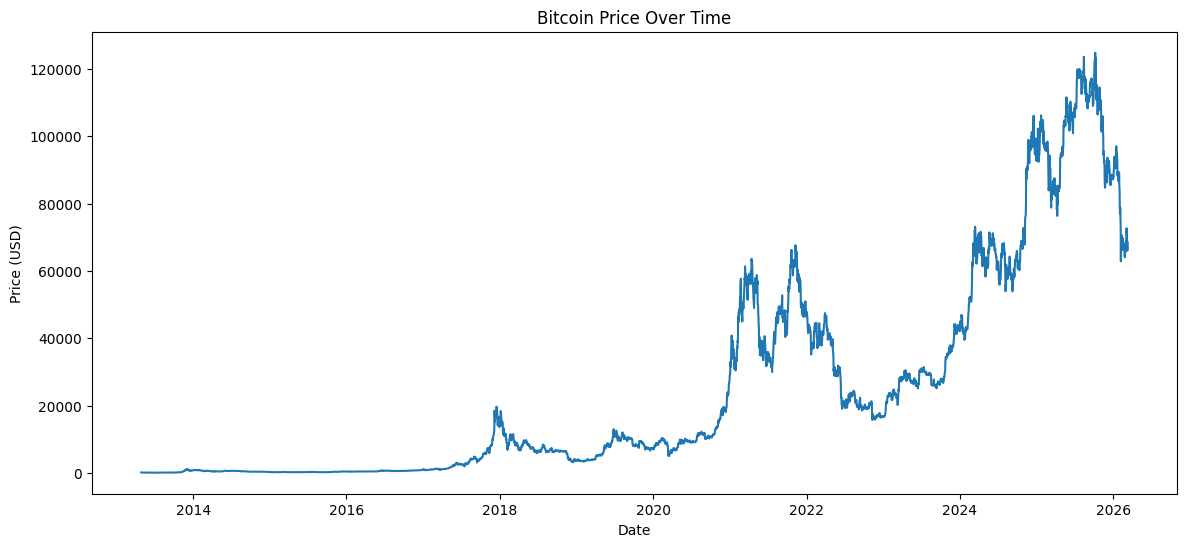

In [9]:
plt.figure(figsize=(14,6))

plt.plot(df['date'], df['price'])

plt.title("Bitcoin Price Over Time")

plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.savefig("../reports/figures/btc_price_trend.png")
plt.show()

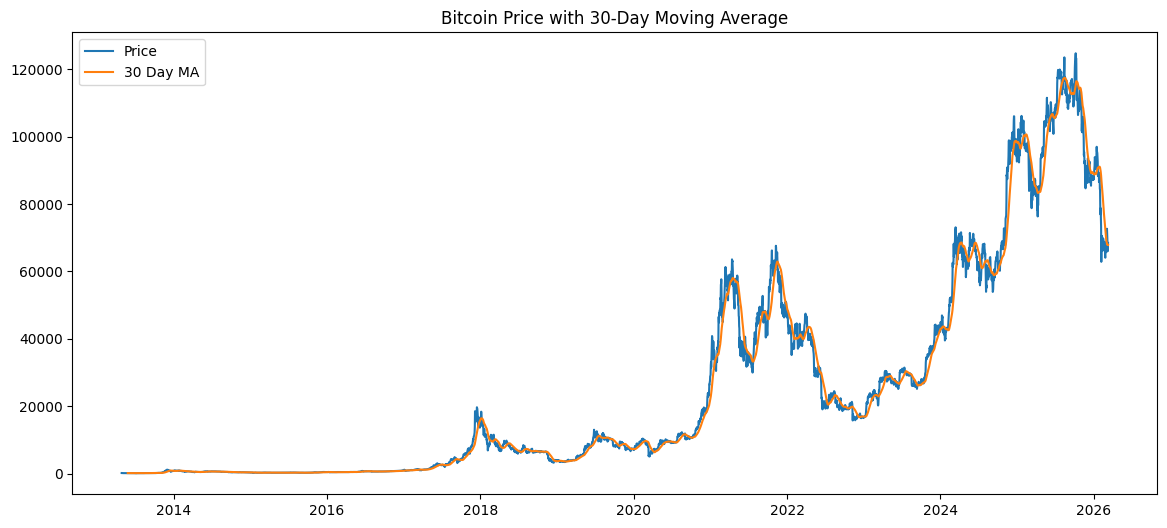

In [ ]:
df['MA30'] = df['price'].rolling(window=30).mean()

plt.figure(figsize=(14,6))

plt.plot(df['date'], df['price'], label="Price")

plt.plot(df['date'], df['MA30'], label="30 Day MA")

plt.legend()

plt.title("Bitcoin Price with 30-Day Moving Average")
plt.savefig("../reports/figures/btc_moving_average.png")
plt.show()

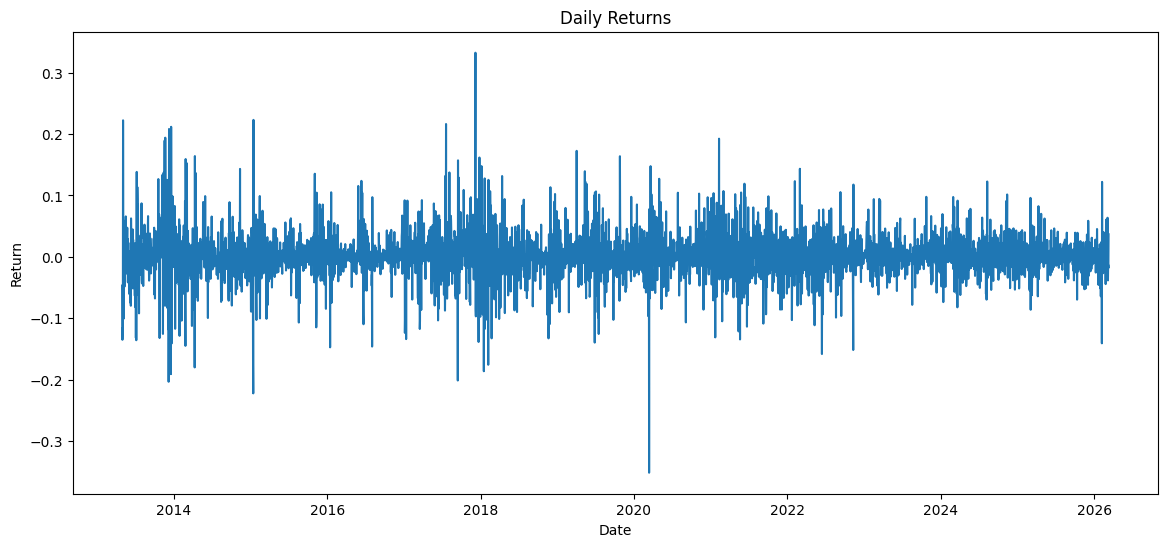

In [ ]:
df['returns'] = df['price'].pct_change()

plt.figure(figsize=(14,6))

plt.plot(df['date'], df['returns'])

plt.title("Daily Returns")

plt.xlabel("Date")

plt.ylabel("Return")
plt.savefig("../reports/figures/btc_daily_returns.png")
plt.show()

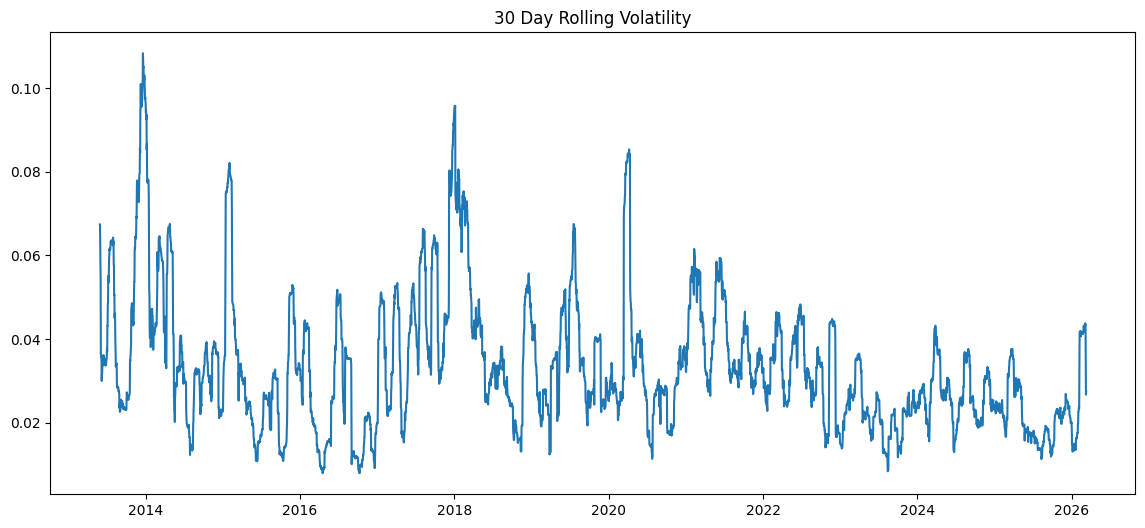

In [ ]:
df['volatility_30'] = df['returns'].rolling(30).std()

plt.figure(figsize=(14,6))

plt.plot(df['date'], df['volatility_30'])

plt.title("30 Day Rolling Volatility")
plt.savefig("../reports/figures/btc_30day_volatility.png")
plt.show()

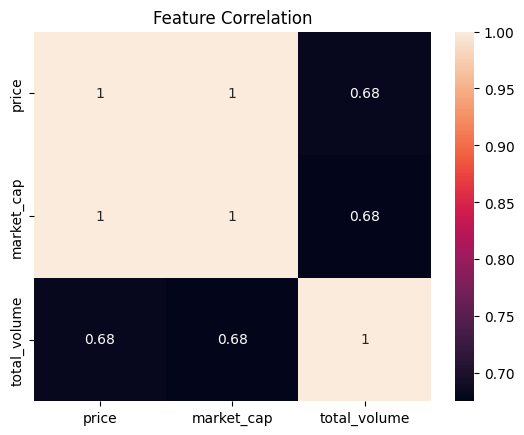

In [ ]:
sns.heatmap(df[['price','market_cap','total_volume']].corr(), annot=True)

plt.title("Feature Correlation")
plt.savefig("../reports/figures/btc_feature_correlation.png")
plt.show()